In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score,roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
import pickle
from churn_prediction.paths import MODELS_OLIST_DIR
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Tải dữ liệu đã xử lý từ Part 1
X_train = np.load(MODELS_OLIST_DIR / 'X_train_exp.npy')
X_val   = np.load(MODELS_OLIST_DIR / 'X_val_exp.npy')
X_test  = np.load(MODELS_OLIST_DIR / 'X_test_exp.npy')
y_train = np.load(MODELS_OLIST_DIR / 'y_train_exp.npy')
y_val   = np.load(MODELS_OLIST_DIR / 'y_val_exp.npy')
y_test  = np.load(MODELS_OLIST_DIR / 'y_test_exp.npy')

In [4]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (67295, 30), Val: (14420, 30), Test: (14421, 30)


In [5]:
# 2. Tải label encoder để lấy tên các lớp cho báo cáo
with open(MODELS_OLIST_DIR / 'experience_label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
class_names = le.classes_   # ['average', 'excellent', 'good', 'poor'] theo thứ tự số

print("Data loaded.")
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Classes: {class_names}")

Data loaded.
Train: 67295, Val: 14420, Test: 14421
Classes: ['average' 'excellent' 'good' 'poor']


In [6]:
# Tính trọng số từ tập train
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, class_weights))
# Tính class weights và sample weights
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, class_weights))
sample_weights = compute_sample_weight('balanced', y=y_train)
# SMOTE (có thể bật/tắt)
use_smote = True
if use_smote:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    # Cần tính lại sample_weights sau SMOTE
    sample_weights = compute_sample_weight('balanced', y=y_train)
# 2. Định nghĩa các mô hình
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight=weight_dict, n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),  # có thể dùng sample_weight khi fit
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, class_weight='balanced', random_state=42, verbose=-1)
}

In [ ]:
# 3. Huấn luyện và đánh giá các mô hình
results = {}
best_f1 = 0
best_model = None
best_name = None

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    if name in ['Gradient Boosting', 'XGBoost']:
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    
    
    # AUC multiclass
    y_proba = model.predict_proba(X_test)
    auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    results[name] = {
        'model': model,
        'auc': auc_macro,
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    print(f"Accuracy: {acc:.4f}, F1-macro: {f1_macro:.4f}, AUC-macro: {auc_macro:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    if f1_macro > best_f1:
        best_f1 = f1_macro
        best_model = model
        best_name = name

print(f"\nBest model: {best_name} with F1-macro = {best_f1:.4f}")


--- Training Logistic Regression ---
Accuracy: 0.5463, F1-macro: 0.5175, AUC-macro: 0.7645
              precision    recall  f1-score   support

     average       0.20      0.69      0.31      1504
   excellent       0.89      0.53      0.67     10676
        good       0.24      0.30      0.26      1534
        poor       0.73      0.96      0.83       707

    accuracy                           0.55     14421
   macro avg       0.51      0.62      0.52     14421
weighted avg       0.74      0.55      0.60     14421


--- Training Random Forest ---
Accuracy: 0.7836, F1-macro: 0.5990, AUC-macro: 0.8020
              precision    recall  f1-score   support

     average       0.40      0.36      0.38      1504
   excellent       0.85      0.92      0.88     10676
        good       0.48      0.20      0.28      1534
        poor       0.79      0.93      0.85       707

    accuracy                           0.78     14421
   macro avg       0.63      0.60      0.60     14421
weighte

In [18]:
# 4. Lưu best model
with open(MODELS_OLIST_DIR / 'best_experience_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"Saved best model to 'best_churn_model.pkl'")

Saved best model to 'best_churn_model.pkl'


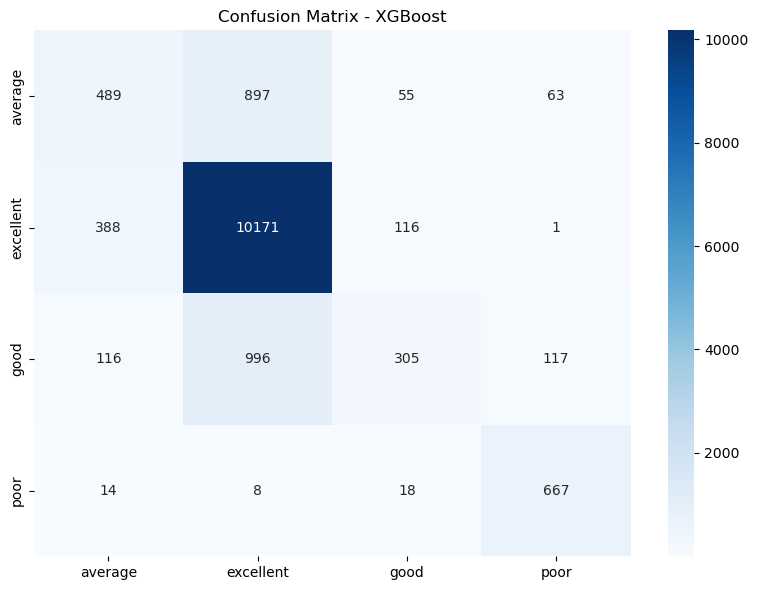

In [19]:
# Confusion matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.savefig(MODELS_OLIST_DIR / 'confusion_matrix_experience.png')
plt.show()